# Proyecto Integrador (TC5035)
# Identificación de Gestos en el Lenguaje de Manos Mexicano
# Avance 3. Baseline
---
## EQUIPO 51
- CARLOS MIGUEL ARVIZU DURÁN - A01410682
- YOHANNA CEBALLOS SALOMÓN - A01795115
- RUBÉN DÍAZ GARCÍA - A01371849

## Profesores
- PROFESOR ASESOR: DR. RAÚL VALENTE RAMÍREZ VELARDE
- PROFESORA TITULAR: DRA. GRETTEL BARCELÓ ALONSO
- PROFESOR TITULAR: DR. LUIS EDUARDO FALCÓN MORALES
- PROFESORA ASISTENTE: MTRA. VERÓNICA SANDRA GUZMÁN DE VALLE

---

# Introducción

Este proyecto se enfoca en el desarrollo de un sistema para la identificación automática de gestos del Lenguaje de Señas Mexicano (LSM) a partir de videos. Utilizando un modelo de red neuronal recurrente, específicamente una LSTM (Long Short-Term Memory), el sistema aprende a reconocer patrones temporales en los movimientos de las manos para clasificar diferentes señas con ayuda de mediapipe.

Para esta fase inicial, se definió un problema de clasificación con cuatro clases específicas: "Abrir", "Avión", "Borrar" y "Tu". Esta selección se basó en la disponibilidad de un conjunto de datos de muestra de la base de datos MX-ITESO-100 (Martínez-Sánchez et al., n.d.) curado que contiene aproximadamente 50 videos para cada uno de estos gestos, lo que permite entrenar y validar el modelo de manera efectiva para una prueba de concepto sólida.

### Liga a la base de datos:
https://drive.google.com/drive/folders/1sy52aJM0FC41JRpHmf3Zr7r3AX7BBpw-?usp=sharing

Es la carpeta data de la estructura de carpetas.

### Estructura de carpetas:

- **data/videos/:** 
Este directorio contiene los videos originales que sirven como entrada al sistema.

Cada seña tiene su propia carpeta, nombrada con el formato ID-Clase (1-Abrir, 2-Avión). Esto permite que los scripts lean fácilmente tanto la etiqueta numérica como el nombre de la clase directamente del nombre de la carpeta.

Dentro de cada carpeta se encuentran los archivos de video (.mp4) correspondientes a esa seña.

- **processed_data_pipeline/:** 
Después de ejecutar el pipeline de preprocesamiento (que extrae los keypoints de las manos, normaliza las secuencias y reduce la dimensionalidad), los datos listos para el entrenamiento se guardan aquí.

X_train.npy y X_test.npy: Son los arreglos de NumPy que contienen las secuencias de características (los datos de entrada X) para los conjuntos de entrenamiento y prueba.

y_train.csv y y_test.csv: Son los archivos CSV con las etiquetas correspondientes (y) para cada secuencia, asegurando que el modelo se entrene y evalúe con los datos correctos.

- **src/:** 
Contiene el código fuente del proyecto, incluyendo el Jupyter Notebook Avance3.51.ipynb con todo el proceso de análisis, preprocesamiento, entrenamiento y evaluación del modelo, así como un archivo de requirements.txt para instalar las dependencias del proyecto y poderlo ejecutar fácilmente.

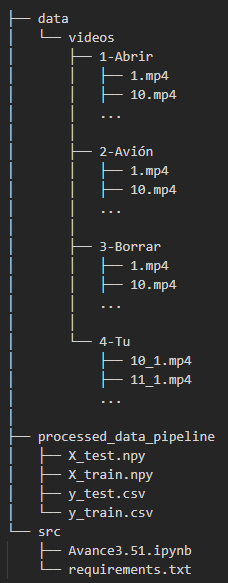

# Análisis
### 1. ¿Qué algoritmo se puede utilizar como baseline para predecir las variables objetivo? (Goodfellow, 2016)

Para un problema de clasificación de secuencias como la identificación de gestos en el Lenguaje de Señas Mexicano, un algoritmo para usar como baseline puede ser una Red Neuronal Recurrente (RNN) simple o una red de Gated Recurrent Units (GRU).

Para este avance se decidió implementar una arquitectura un poco más compleja y potente, una Long Short-Term Memory (LSTM). Aunque existen modelos teóricamente más "simples", el LSTM ofrece un punto de partida robusto que aborda directamente los desafíos inherentes a los datos secuenciales, como los videos de gestos.

Ventajas clave:

- Superación del Problema del Gradiente Desvanecido (Memoria a Largo Plazo)
El principal inconveniente de las Redes Neuronales Recurrentes (RNN) simples es su dificultad para aprender dependencias en secuencias largas. Esto se debe al problema del gradiente desvanecido, donde la información de los primeros fotogramas se pierde a medida que la red procesa el resto del video. El LSTM fue diseñado específicamente para solucionar esto.

- Modelado Explícito de la Estructura Temporal
Los gestos no son imágenes estáticas, sino secuencias dinámicas donde el orden es todo. El LSTM tiene ventaja contra los métodos no secuenciales, por ejemplo, si se hubieran utilizado métodos tradicionales como un Perceptrón Multicapa (MLP) o un Support Vector Machine (SVM), se habría tenido que "aplanar" la información de todos los fotogramas del video en un solo vector gigante. Este proceso destruye por completo la información temporal.

- Establecimiento de un Baseline Sólido
Un baseline no tiene por qué ser el modelo más simple posible, sino uno que establezca un punto de comparación significativo. Al ser un estándar de la industria para el análisis de secuencias, un LSTM proporciona un baseline muy fuerte. El hecho de que este modelo alcanzara un 95% de precisión demuestra no solo que el problema es resoluble, sino que establece un estándar de rendimiento muy alto.



### 2. ¿Se puede determinar la importancia de las características para el modelo generado? Recuerden que incluir características irrelevantes puede afectar negativamente el rendimiento del modelo y aumentar la complejidad sin beneficios sustanciales.

Sí, es posible determinar la importancia de las características, y de hecho, el pipeline de preprocesamiento ya realiza un paso crucial para ello. El transformador TemporalFeatureProcessor utiliza el Análisis de Componentes Principales (PCA).

PCA reduce la dimensionalidad del conjunto de datos al transformar las características originales (coordenadas y velocidades de los puntos de la mano) en un nuevo conjunto de características no correlacionadas llamadas componentes principales. Estos componentes se ordenan según la cantidad de varianza de los datos originales que explican.

En la ejecución del notebook, se configuró PCA para retener el 95% de la varianza (n_components=0.95), lo que resultó en la reducción de las características a solo 5 componentes principales. Esto demuestra que una gran parte de la información relevante está contenida en estas 5 dimensiones, eliminando características irrelevantes o redundantes que podrían afectar negativamente el rendimiento y la eficiencia del modelo.



### 3. ¿El modelo está sub/sobreajustando los datos de entrenamiento?

Observando las gráficas de "Precisión del Modelo" y "Pérdida del Modelo", se puede concluir que el modelo muestra signos leves de sobreajuste (overfitting) hacia el final del entrenamiento.

* Precisión: La precisión de entrenamiento alcanza casi el 100%, mientras que la precisión de validación se estabiliza y es ligeramente inferior (alcanzando un 100% en algunas épocas, pero mostrando más variabilidad).

* Pérdida: La pérdida de entrenamiento disminuye consistentemente, pero la pérdida de validación comienza a aumentar en las últimas épocas. Esta divergencia es un indicador clásico de sobreajuste, donde el modelo comienza a memorizar los datos de entrenamiento en lugar de generalizar.

A pesar de esto, el sobreajuste no es severo, ya que el rendimiento en el conjunto de validación sigue siendo muy alto. Las capas de Dropout con un valor de 0.5 en el modelo están ayudando a mitigar este efecto.



### 4. ¿Cuál es la métrica adecuada para este problema de negocio? 

Para este problema de clasificación multiclase, la métrica principal más adecuada es la Precisión (Accuracy). Esta métrica nos da una visión general y rápida de qué tan bien el modelo predice correctamente los gestos. Dado que el objetivo es crear un sistema de traducción funcional, es fundamental que la mayoría de los gestos se identifiquen correctamente.

Además, es importante considerar:
- Precisión (Precision), Recall y F1-Score por clase: El reporte de clasificación muestra estas métricas para cada gesto. Son cruciales para entender si el modelo tiene dificultades con algún gesto en particular. Un F1-score alto y balanceado para todas las clases es ideal.
- Matriz de Confusión: Es una herramienta visual excelente para identificar exactamente qué gestos se están confundiendo entre sí, lo cual es vital para futuras mejoras del modelo.

En el reporte generado, se observa una precisión general del 95%, y F1-scores altos y balanceados (0.95, 0.95, 0.95, 0.95), lo que indica un excelente rendimiento del modelo.




### 5. ¿Cuál debería ser el desempeño mínimo a obtener?

Dado que se trata de un problema de clasificación con 4 clases diferentes ("Abrir", "Avión", "Borrar", "Tu"), un modelo que adivina al azar tendría una precisión de aproximadamente el 25%. Por lo tanto, cualquier desempeño significativamente superior a este valor se considera un aprendizaje exitoso.

Considerando la aplicación práctica de un traductor de lenguaje de señas, un desempeño mínimo aceptable debería ser considerablemente más alto para ser útil. Un buen punto de partida como desempeño mínimo deseable sería una precisión superior al 80-85%.

El modelo actual supera este umbral, alcanzando una precisión del 95%, lo que lo establece como un modelo de referencia (baseline) muy sólido y efectivo.


# Bibliografía:

- Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep learning. MIT Press.
- Martínez-Sánchez, V., Villalón-Turrubiates, I., Cervantes-Álvarez, F., & HernándezMejía, C. (n.d.). Exploring a novel Mexican Sign Language Lexicon Video Dataset. [v1]
| Preprints.org. https://www.preprints.org/manuscript/202307.1125/v1
- MediaPipe Solutions guide. (n.d.). Google AI for Developers.
https://ai.google.dev/edge/mediapipe/solutions/guide


# Imports:

In [1]:
import os
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical
from tqdm import tqdm

2025-10-12 22:03:05.217608: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-12 22:03:05.276300: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760328185.309560  440644 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760328185.321892  440644 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1760328185.364198  440644 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

# Funciones:

## Data Loader:

In [2]:
# Estructura esperada: videos/{class_id}-{class_name}/{video_id}.mp4
# Escanea las carpetas con los videos en la estructura esperada y crea un dataframe
def create_dataframe_from_folders(videos_dir):
    rows = []
    print(f"Escaneando '{videos_dir}'...")

    if not os.path.isdir(videos_dir):
        print(f"Error: El directorio '{videos_dir}' no existe.")
        return pd.DataFrame()

    # Itera sobre cada subdirectorio en la carpeta de videos
    for folder_name in sorted(os.listdir(videos_dir)):
        folder_path = os.path.join(videos_dir, folder_name)

        if os.path.isdir(folder_path):
            try:
                # Se extrae el ID y el nombre de la clase del nombre de la carpeta
                class_id, class_name = folder_name.split('-', 1)
            except ValueError:
                print(f" Carpeta omitida: '{folder_name}'")
                continue

            # Itera sobre cada archivo dentro de la carpeta de la clase
            for video_file in os.listdir(folder_path):
                if video_file.endswith('.mp4'):
                    video_id = video_file.split('.')[0]
                    
                    video_path = os.path.join(folder_path, video_file)
                    rows.append({
                        'class_id': class_id,   # Columna para el ID
                        'class': class_name,    # Columna para la clase
                        'video_id': video_id,   # Columna para el nombre
                        'video_path': video_path
                    })
    
    if not rows:
        print("Error: No se encontraron videos.")
        return pd.DataFrame()

    df = pd.DataFrame(rows)
    print(f"DataFrame creado! \nContiene {len(df)} videos de {df['class'].nunique()} clases distintas.")
    return df

## Feature Extraction:

In [3]:
class FeatureExtractor:
    def __init__(self):
        self.mp_hands = mp.solutions.hands
        self.hands = self.mp_hands.Hands(
            static_image_mode=False,
            max_num_hands=2,
            min_detection_confidence=0.5,
            min_tracking_confidence=0.5
        )
        # El vector de características por frame tendrá 21 (puntos) * 3 (coords) * 2 (manos) = 126
        self.feature_vector_size = 21 * 3 * 2

    #Procesa un video y extrae los 21 puntos de referencia 3D de hasta 2 manos por frame
    def extract_hand_keypoints(self, video_path):
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            print(f"Error: No se pudo abrir el video {video_path}")
            return None

        video_keypoints = []
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            # Procesamiento con MediaPipe
            image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = self.hands.process(image_rgb)
            frame_keypoints = np.zeros(self.feature_vector_size)

            if results.multi_hand_landmarks:
                # Itera sobre cada mano detectada
                for i, hand_landmarks in enumerate(results.multi_hand_landmarks):
                    if i >= 2: continue # Limitación para 2 manos
                    # Extrae los landmarks y los aplana en un array
                    landmarks = np.array(
                        [[lm.x, lm.y, lm.z] for lm in hand_landmarks.landmark]
                    ).flatten()
                    # Asigna los landmarks al array del frame
                    # Mano 0: índices 0-62, Mano 1: índices 63-125
                    start_index = i * (21 * 3)
                    end_index = start_index + len(landmarks)
                    frame_keypoints[start_index:end_index] = landmarks
            video_keypoints.append(frame_keypoints)
        cap.release()
        return np.array(video_keypoints)

    # Calculamos la velocidad (diferencia entre frames).
    def calculate_kinematic_features(self, keypoints_sequence):
        # Si hay menos de 2 frames, no se puede calcular velocidad
        if keypoints_sequence.shape[0] < 2:
            return np.zeros_like(keypoints_sequence)
        # Calcula la diferencia entre frames consecutivos para obtener la velocidad
        velocities = np.diff(keypoints_sequence, axis=0)
        # Añade un frame de velocidad cero al principio para mantener la misma longitud
        velocities = np.vstack([np.zeros(velocities.shape[1]), velocities])
        return velocities

    # Función de extracción de características 
    def process_video(self, video_path):
        # Extracción de puntos de referencia
        keypoints = self.extract_hand_keypoints(video_path)
        if keypoints is None or keypoints.shape[0] == 0:
            return None
        # Generación de nuevas características (velocidad)
        velocities = self.calculate_kinematic_features(keypoints)
        # Combinar las características (coordenadas + velocidad)
        combined_features = np.hstack([keypoints, velocities])
        
        return combined_features

In [4]:
class VideoFeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self):
        # Inicializa una sola vez para evitar recargar el modelo de MediaPipe
        self.extractor = FeatureExtractor()

    def fit(self, X, y=None):
        # Este transformador no necesita "aprender" nada, así que solo devuelve self
        return self

    # X: lista o serie de Pandas con rutas a los videos
    def transform(self, X, y=None):
        all_sequences = []
        print("Paso 1/3: Extrayendo características de los videos...")
        for video_path in tqdm(X, desc="Extrayendo secuencias"):
            features = self.extractor.process_video(video_path)
            # Solo añade secuencias válidas
            if features is not None and features.shape[0] > 0:
                all_sequences.append(features)
        return all_sequences

# Estandariza la longitud de las secuencias mediante padding
class SequencePadder(BaseEstimator, TransformerMixin):
    def __init__(self, percentile=95):
        self.percentile = percentile
        self.target_frames_ = 0

    # Aprende la longitud objetivo a partir de los datos de entrenamiento
    def fit(self, X, y=None):
        sequence_lengths = [seq.shape[0] for seq in X]
        if sequence_lengths:
            self.target_frames_ = int(np.percentile(sequence_lengths, self.percentile))
        print(f"Longitud de secuencia objetivo aprendida: {self.target_frames_} fotogramas.")
        return self

    # Aplica padding a cada secuencia en X.
    def transform(self, X, y=None):
        print("Paso 2/3: Estandarizando longitud de secuencias...")
        processed_sequences = []
        for seq in tqdm(X, desc="Padding"):
            num_frames, num_features = seq.shape
            
            if num_frames > self.target_frames_:
                processed_seq = seq[:self.target_frames_, :]
            elif num_frames < self.target_frames_:
                pad_width = self.target_frames_ - num_frames
                padding = np.zeros((pad_width, num_features))
                processed_seq = np.vstack([seq, padding])
            else:
                processed_seq = seq
            
            processed_sequences.append(processed_seq)
        return np.array(processed_sequences)

# Aplicamos transformadores a nivel de característica a datos 3D temporales
class TemporalFeatureProcessor(BaseEstimator, TransformerMixin):
    def __init__(self, n_components=0.95):
        self.n_components = n_components
        # Define un pipeline interno para el procesamiento de características
        self.feature_pipeline_ = Pipeline([
            ('scaler', MinMaxScaler()),
            ('pca', PCA(n_components=self.n_components))
        ])

    # Ajusta el pipeline de características en los datos aplanados
    def fit(self, X, y=None):
        n_videos, n_frames, n_features = X.shape
        # Aplana los datos a 2D para ajustar el scaler y PCA
        reshaped_data = X.reshape(-1, n_features)
        self.feature_pipeline_.fit(reshaped_data)
        print("Scaler y PCA ajustados.")
        return self

    # Aplica el pipeline de características y devuelve los datos en formato 3D
    def transform(self, X, y=None):
        print("Paso 3/3: Aplicando Scaler y PCA a nivel de fotograma...")
        n_videos, n_frames, n_features = X.shape
        # Aplana, transforma y luego remodela de vuelta a 3D
        reshaped_data = X.reshape(-1, n_features)
        transformed_data = self.feature_pipeline_.transform(reshaped_data)
        
        # El número de características ahora es el número de componentes de PCA
        n_transformed_features = transformed_data.shape[1]
        final_data = transformed_data.reshape(n_videos, n_frames, n_transformed_features)
        
        print(f"Características reducidas a {n_transformed_features} componentes.")
        return final_data

# Main Code:

In [5]:
# CONFIGURACIÓN: se debe ajustar a la carpeta desde donde se corre el programa
notebook_dir = Path.cwd() 
current_script_dir = notebook_dir#.parent
parent_dir = current_script_dir
PROCESSED_DATA_DIR = parent_dir / "processed_data_pipeline"
data_dir = parent_dir / "data"
VIDEOS_DIR =  data_dir / "videos"

print(f"\nPaths: \nPROCESSED DATA DIRECTORY: {PROCESSED_DATA_DIR} \nVIDEOS DIRECTORY: {VIDEOS_DIR}")


Paths: 
PROCESSED DATA DIRECTORY: /mnt/d/Code/MNA/MNA/PI/lsm/processed_data_pipeline 
VIDEOS DIRECTORY: /mnt/d/Code/MNA/MNA/PI/lsm/data/videos


In [6]:
# --- Cargar metadatos ---
print("--- Carga de Metadatos desde Carpetas ---")
df = create_dataframe_from_folders(VIDEOS_DIR)

if df.empty:
    print("No se encontraron datos para procesar.")
    exit()

# Separar características (X) y etiquetas (y)
X = df['video_path']
y = df['class']

# Dividir los datos ANTES del preprocesamiento para evitar fuga de datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nDatos divididos: {len(X_train)} para entrenamiento, {len(X_test)} para prueba.")

--- Carga de Metadatos desde Carpetas ---
Escaneando '/mnt/d/Code/MNA/MNA/PI/lsm/data/videos'...
DataFrame creado! 
Contiene 205 videos de 4 clases distintas.

Datos divididos: 164 para entrenamiento, 41 para prueba.


In [7]:
# --- Definir el Pipeline de Preprocesamiento ---
print("\n--- Definición del Pipeline ---")

preprocessing_pipeline = Pipeline([
    ('1_video_feature_extraction', VideoFeatureExtractor()),
    ('2_sequence_padding', SequencePadder(percentile=95)),
    ('3_feature_processing', TemporalFeatureProcessor(n_components=0.95))
])


--- Definición del Pipeline ---


libEGL warning: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)



INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1760328189.239273  440724 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [8]:
# --- Ejecutar el Pipeline ---
print("\n--- Ejecutando el Pipeline en los Datos de Entrenamiento ---")
# Ajusta y transforma los datos de entrenamiento
X_train_processed = preprocessing_pipeline.fit_transform(X_train)

print("\n--- Ejecutando el Pipeline en los Datos de Prueba ---")
# Solo transforma los datos de prueba (usando los parámetros aprendidos del entrenamiento)
X_test_processed = preprocessing_pipeline.transform(X_test)


--- Ejecutando el Pipeline en los Datos de Entrenamiento ---
Paso 1/3: Extrayendo características de los videos...


Extrayendo secuencias:   0%|                                                                                 | 0/164 [00:00<?, ?it/s]W0000 00:00:1760328189.265651  440724 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
/home/raven/miniconda3/envs/wlasl_project/lib/python3.9/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
Extrayendo secuencias: 100%|███████████████████████████████████████████████████████████████████████| 164/164 [09:56<00:00,  3.64s/it]


Longitud de secuencia objetivo aprendida: 150 fotogramas.
Paso 2/3: Estandarizando longitud de secuencias...


Padding: 100%|████████████████████████████████████████████████████████████████████████████████| 164/164 [00:00<00:00, 1630013.88it/s]


Scaler y PCA ajustados.
Paso 3/3: Aplicando Scaler y PCA a nivel de fotograma...
Características reducidas a 5 componentes.

--- Ejecutando el Pipeline en los Datos de Prueba ---
Paso 1/3: Extrayendo características de los videos...


Extrayendo secuencias:   0%|                                                                                  | 0/41 [00:00<?, ?it/s]/home/raven/miniconda3/envs/wlasl_project/lib/python3.9/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
Extrayendo secuencias: 100%|█████████████████████████████████████████████████████████████████████████| 41/41 [02:27<00:00,  3.60s/it]


Paso 2/3: Estandarizando longitud de secuencias...


Padding: 100%|███████████████████████████████████████████████████████████████████████████████████| 41/41 [00:00<00:00, 504300.48it/s]

Paso 3/3: Aplicando Scaler y PCA a nivel de fotograma...
Características reducidas a 5 componentes.


In [9]:
# --- Guardar los resultados ---
print("\n--- Guardando los Datos Procesados ---")
output_dir = "processed_data_pipeline"
os.makedirs(output_dir, exist_ok=True)

# Guardar datos de entrenamiento
np.save(os.path.join(output_dir, "X_train.npy"), X_train_processed)
y_train.to_csv(os.path.join(output_dir, "y_train.csv"), index=False, header=True)

# Guardar datos de prueba
np.save(os.path.join(output_dir, "X_test.npy"), X_test_processed)
y_test.to_csv(os.path.join(output_dir, "y_test.csv"), index=False, header=True)

print(f"\nProcesamiento completado!")
print(f"Datos guardados en la carpeta '{output_dir}'.")
print(f"Forma de los datos de entrenamiento (X_train.npy): {X_train_processed.shape}")
print(f"Forma de los datos de prueba (X_test.npy): {X_test_processed.shape}")


--- Guardando los Datos Procesados ---

Procesamiento completado!
Datos guardados en la carpeta 'processed_data_pipeline'.
Forma de los datos de entrenamiento (X_train.npy): (164, 150, 5)
Forma de los datos de prueba (X_test.npy): (41, 150, 5)


# Training:

In [10]:
# --- Cargar los Datos Preprocesados ---
print("--- Cargando datos preprocesados ---")
X_train = np.load(os.path.join(PROCESSED_DATA_DIR, "X_train.npy"))
X_test = np.load(os.path.join(PROCESSED_DATA_DIR, "X_test.npy"))
y_train_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "y_train.csv"))
y_test_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "y_test.csv"))
y_train_labels = y_train_df['class'].values
y_test_labels = y_test_df['class'].values

print(f"Forma de X_train: {X_train.shape}")
print(f"Forma de X_test: {X_test.shape}")

--- Cargando datos preprocesados ---
Forma de X_train: (164, 150, 5)
Forma de X_test: (41, 150, 5)


In [11]:
# --- Codificar las Etiquetas ---
print("\n--- Codificando las etiquetas ---")
label_encoder = LabelEncoder()
all_labels = np.concatenate([y_train_labels, y_test_labels])
label_encoder.fit(all_labels)
y_train_encoded = label_encoder.transform(y_train_labels)
y_test_encoded = label_encoder.transform(y_test_labels)
num_classes = len(label_encoder.classes_)
y_train_categorical = to_categorical(y_train_encoded, num_classes=num_classes)
y_test_categorical = to_categorical(y_test_encoded, num_classes=num_classes)
print(f"Número de clases únicas: {num_classes}")


--- Codificando las etiquetas ---
Número de clases únicas: 4


In [12]:
# --- Construir el Modelo LSTM ---
print("\n--- Construyendo la arquitectura del modelo LSTM ---")
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(64, return_sequences=True),
    Dropout(0.5),
    LSTM(64, return_sequences=False),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])


--- Construyendo la arquitectura del modelo LSTM ---


W0000 00:00:1760328934.269304  440644 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [13]:
# --- Compilar el Modelo ---
print("\n--- Compilando el modelo ---")
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])
model.summary()


--- Compilando el modelo ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 150, 64)        │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 150, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,364 (216.27 KB)

 Trainable params: 55,364 (216.27 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# --- Entrenar el Modelo ---
print("\n--- Entrenando el modelo ---")
history = model.fit(
    X_train, 
    y_train_categorical,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test_categorical),
    verbose=1
)


--- Entrenando el modelo ---
Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - accuracy: 0.3744 - loss: 1.3226 - val_accuracy: 0.8293 - val_loss: 1.0426
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.6578 - loss: 1.0669 - val_accuracy: 0.8049 - val_loss: 0.8174
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.7371 - loss: 0.9347 - val_accuracy: 0.8049 - val_loss: 0.6443
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.7507 - loss: 0.7565 - val_accuracy: 0.8293 - val_loss: 0.5035
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.7765 - loss: 0.6751 - val_accuracy: 0.8780 - val_loss: 0.3829
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8559 - loss: 0.5651 - val_accuracy: 0.9268 - val_loss: 0.2316
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8800 - loss: 0.4097 - val_accuracy: 0.9756 - val_loss: 0.1400
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8812 - loss: 0.3632 - val_accur


--- Evaluando el modelo con métricas detalladas ---
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

       Abrir       1.00      0.90      0.95        10
       Avión       0.91      1.00      0.95        10
      Borrar       1.00      0.91      0.95        11
          Tu       0.91      1.00      0.95        10

    accuracy                           0.95        41
   macro avg       0.95      0.95      0.95        41
weighted avg       0.96      0.95      0.95        41


--- Matriz de Confusión ---


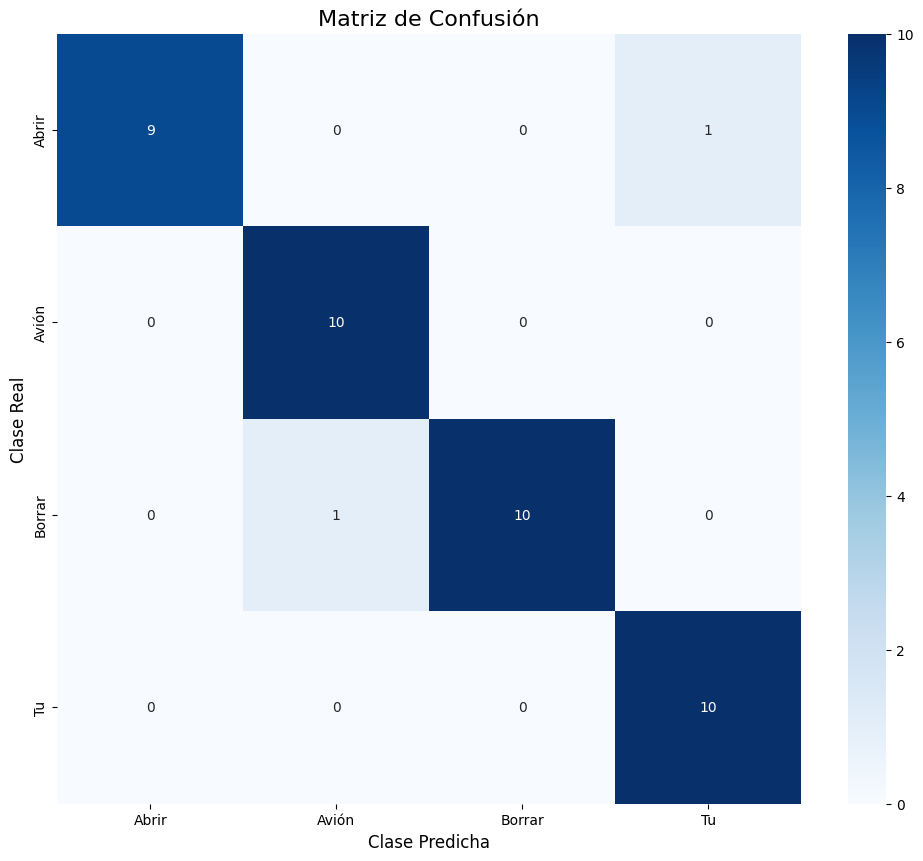


--- Gráfica de precisión y pérdida durante el entrenamiento ---


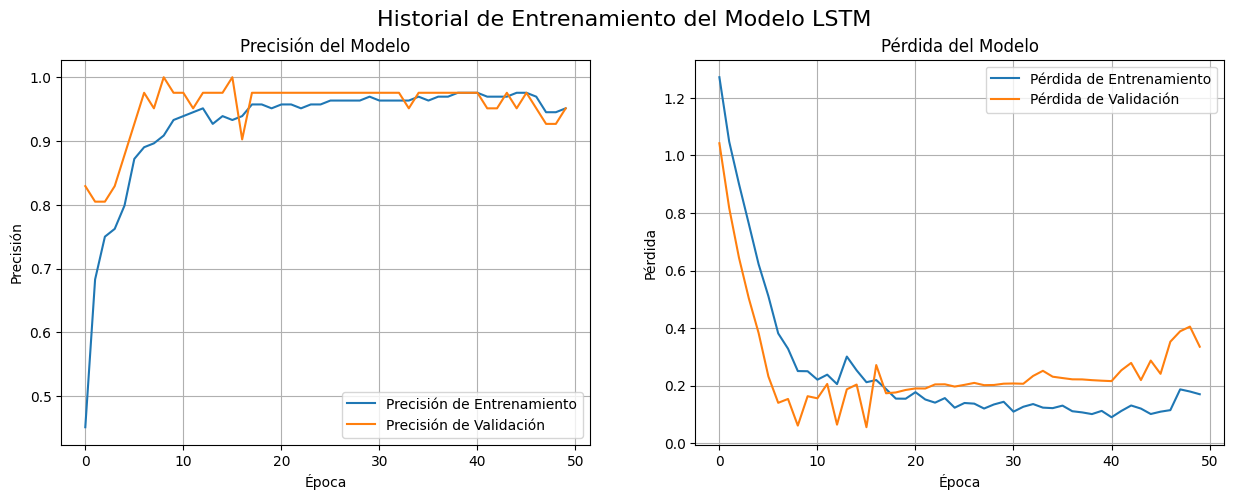


Entrenamiento completado!


In [15]:
# --- Evaluar y Visualizar los Resultados ---
print("\n--- Evaluando el modelo con métricas detalladas ---")

# Realizar predicciones en el conjunto de prueba
y_pred_probabilities = model.predict(X_test)
# Convertir las probabilidades a etiquetas de clase predichas (la de mayor probabilidad)
y_pred_encoded = np.argmax(y_pred_probabilities, axis=1)

# Generar y mostrar el Reporte de Clasificación
print("\n--- Reporte de Clasificación ---")
# Reporte: precisión, recall y f1-score para cada clase.
report = classification_report(y_test_encoded, y_pred_encoded, target_names=label_encoder.classes_)
print(report)

# Generar y mostrar la Matriz de Confusión
print("\n--- Matriz de Confusión ---")
cm = confusion_matrix(y_test_encoded, y_pred_encoded)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title('Matriz de Confusión', fontsize=16)
plt.ylabel('Clase Real', fontsize=12)
plt.xlabel('Clase Predicha', fontsize=12)
plt.show()

# Graficar la precisión y la pérdida durante el entrenamiento
print("\n--- Gráfica de precisión y pérdida durante el entrenamiento ---")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
# Gráfica de Precisión
ax1.plot(history.history['accuracy'], label='Precisión de Entrenamiento')
ax1.plot(history.history['val_accuracy'], label='Precisión de Validación')
ax1.set_title('Precisión del Modelo')
ax1.set_xlabel('Época')
ax1.set_ylabel('Precisión')
ax1.legend()
ax1.grid(True)
# Gráfica de Pérdida
ax2.plot(history.history['loss'], label='Pérdida de Entrenamiento')
ax2.plot(history.history['val_loss'], label='Pérdida de Validación')
ax2.set_title('Pérdida del Modelo')
ax2.set_xlabel('Época')
ax2.set_ylabel('Pérdida')
ax2.legend()
ax2.grid(True)
plt.suptitle('Historial de Entrenamiento del Modelo LSTM', fontsize=16)
plt.show()

print("\nEntrenamiento completado!")